# Practice 3 - Customer Clustering: DBSCAN

**Nhiệm vụ cá nhân:** triển khai và kiểm thử thuật toán **DBSCAN** cho bài thực hành phân cụm khách hàng.

Notebook này được viết theo yêu cầu của nhóm:

- Vì dữ liệu `ready_for_train.csv` chưa hoàn thiện nên notebook dùng **dummy data** để test thuật toán.
- Dummy data được **sinh trực tiếp bằng code**, không lưu thành file `.csv`, vì vậy không cần push dataset phụ lên GitHub.
- Khi preprocessing/feature engineering hoàn tất, chỉ cần đổi `USE_DUMMY_DATA = False` và kiểm tra lại đường dẫn `REAL_DATA_PATH`.
- Có cả phần **DBSCAN From Scratch** và **sklearn.cluster.DBSCAN** để đối chiếu kết quả.
- Có phần tìm `eps` bằng **k-distance plot**.
- Có phần so sánh **DBSCAN với K-Means** trên dữ liệu không có dạng hình cầu.

## 0. Vai trò của DBSCAN trong Practice 3

Practice 3 là bài toán **Unsupervised Learning - Customer Clustering**. Mục tiêu chung là phân cụm khách hàng dựa trên các đặc trưng đã được EDA, preprocessing và feature engineering.

Trong notebook này, DBSCAN được dùng để kiểm tra khả năng phân cụm theo mật độ. Khác với K-Means, DBSCAN không bắt buộc phải khai báo trước số cụm `K` và có khả năng phát hiện điểm nhiễu/outlier thông qua nhãn `-1`.

Do dữ liệu thật chưa có file `ready_for_train`, phần kiểm thử hiện tại dùng dữ liệu giả lập dạng `make_moons`. Đây là bộ dữ liệu minh họa tốt cho DBSCAN vì cụm có dạng cong, không hình cầu, giúp thấy rõ hạn chế của K-Means.

## 1. Import thư viện

In [1]:
import os
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

RANDOM_STATE = 42

## 2. Cấu hình dữ liệu

Hiện tại nhóm chưa có file `ready_for_train.csv`, nên để đúng yêu cầu nhóm trưởng, notebook dùng dummy data để test thuật toán.

Khi data thật đã xong, sửa:

```python
USE_DUMMY_DATA = False
REAL_DATA_PATH = './data/processed/ready_for_train.csv'
```

Lưu ý: không push dummy dataset lên GitHub. Ở đây dummy data được sinh trực tiếp bằng code nên chỉ cần push notebook.

In [2]:
USE_DUMMY_DATA = True
REAL_DATA_PATH = './data/processed/ready_for_train.csv'

## 3. Hàm load dữ liệu

Hàm dưới đây có 2 chế độ:

- Nếu `USE_DUMMY_DATA = True`: sinh dummy data bằng `make_moons` và thêm một số điểm nhiễu.
- Nếu `USE_DUMMY_DATA = False`: đọc dữ liệu thật từ `REAL_DATA_PATH`, chỉ lấy các cột số để chạy clustering.

Trong bài toán thật, dữ liệu sau preprocessing/feature engineering nên đã được mã hóa biến phân loại, xử lý missing values và chuẩn hóa/biến đổi phù hợp.

In [3]:
def load_data_for_dbscan(data_path: str = REAL_DATA_PATH, use_dummy: bool = USE_DUMMY_DATA):
    """
    Load dữ liệu cho DBSCAN.

    Parameters
    ----------
    data_path : str
        Đường dẫn tới file dữ liệu thật sau preprocessing/feature engineering.
    use_dummy : bool
        True: dùng dummy data để test thuật toán.
        False: đọc dữ liệu thật nếu file đã tồn tại.

    Returns
    -------
    X : np.ndarray
        Ma trận đặc trưng đầu vào.
    y_true : np.ndarray | None
        Nhãn thật của dummy data, chỉ dùng để đánh giá minh họa. Với dữ liệu thật thì None.
    source : str
        Mô tả nguồn dữ liệu.
    """
    if os.path.exists(data_path) and not use_dummy:
        df = pd.read_csv(data_path)

        # Với dữ liệu đã feature engineering, các cột dùng để train nên là numeric.
        numeric_df = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).copy()
        numeric_df = numeric_df.dropna()

        if numeric_df.shape[1] < 2:
            raise ValueError('Dữ liệu thật cần ít nhất 2 numeric features để phân cụm/trực quan hóa.')

        X = numeric_df.values
        y_true = None
        source = f'Real data from {data_path}'
    else:
        # Dummy dataset: hai cụm dạng nửa vòng tròn, không có dạng hình cầu.
        X, y_true = make_moons(n_samples=600, noise=0.07, random_state=RANDOM_STATE)

        # Thêm nhiễu/outlier để kiểm tra khả năng nhận diện noise của DBSCAN.
        rng = np.random.default_rng(RANDOM_STATE)
        noise = rng.uniform(low=[-1.5, -0.8], high=[2.5, 1.4], size=(45, 2))
        X = np.vstack([X, noise])
        y_true = np.concatenate([y_true, np.full(len(noise), -1)])

        source = 'Dummy make_moons + random noise generated in notebook'

    return X, y_true, source


X_raw, y_true, data_source = load_data_for_dbscan()
print(data_source)
print('Shape:', X_raw.shape)

Dummy make_moons + random noise generated in notebook
Shape: (645, 2)


## 4. Chuẩn hóa dữ liệu

DBSCAN phụ thuộc trực tiếp vào khoảng cách giữa các điểm dữ liệu. Vì vậy cần chuẩn hóa dữ liệu trước khi chạy thuật toán, đặc biệt khi các feature có thang đo khác nhau.

In [4]:
def scale_features(X):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled, scaler


X_scaled, scaler = scale_features(X_raw)
print('Mean sau chuẩn hóa:', np.round(X_scaled.mean(axis=0), 4))
print('Std sau chuẩn hóa:', np.round(X_scaled.std(axis=0), 4))

Mean sau chuẩn hóa: [ 0. -0.]
Std sau chuẩn hóa: [1. 1.]


## 5. Trực quan dữ liệu ban đầu

Ở dummy data, `y_true` chỉ dùng để kiểm tra trực quan và đánh giá minh họa. Khi chuyển sang dữ liệu khách hàng thật, bài toán là unsupervised nên không dùng nhãn phân khúc để train.

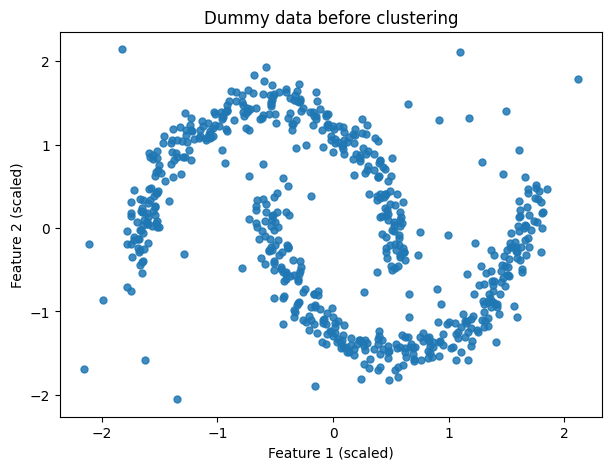

In [5]:
def plot_2d_clusters(X, labels, title, ax=None):
    """Vẽ scatter plot 2D cho dữ liệu phân cụm."""
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))

    ax.scatter(X[:, 0], X[:, 1], c=labels, s=25, alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel('Feature 1 (scaled)')
    ax.set_ylabel('Feature 2 (scaled)')
    return ax


plt.figure(figsize=(7, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], s=25, alpha=0.85)
plt.title('Dummy data before clustering')
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')
plt.show()

## 6. Tìm `eps` bằng k-distance plot

DBSCAN có 2 tham số quan trọng:

- `eps`: bán kính lân cận của một điểm.
- `min_samples`: số điểm tối thiểu trong vùng bán kính `eps` để một điểm được xem là core point.

Cách làm k-distance plot:

1. Chọn `min_samples`.
2. Tính khoảng cách từ mỗi điểm đến người hàng xóm thứ `min_samples`.
3. Sắp xếp các khoảng cách tăng dần.
4. Quan sát vùng “khuỷu tay” của đường cong để chọn `eps`.

Trong notebook này, để code chạy tự động, ta lấy gợi ý `eps` bằng percentile. Khi làm báo cáo, nên nhìn biểu đồ và có thể chỉnh lại `eps` thủ công.

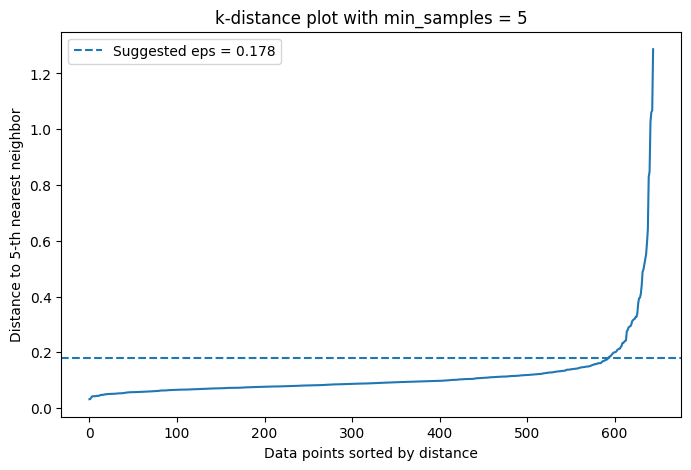

Suggested EPS: 0.1781


In [6]:
def k_distance_values(X, min_samples=5):
    """Trả về khoảng cách tới láng giềng thứ min_samples của từng điểm, đã sắp xếp tăng dần."""
    neighbors = NearestNeighbors(n_neighbors=min_samples)
    neighbors.fit(X)
    distances, _ = neighbors.kneighbors(X)
    kth_distances = np.sort(distances[:, -1])
    return kth_distances


def suggest_eps_by_percentile(kth_distances, percentile=92):
    """Gợi ý eps tự động để notebook chạy được; vẫn nên kiểm tra lại bằng biểu đồ."""
    return float(np.percentile(kth_distances, percentile))


MIN_SAMPLES = 5
k_distances = k_distance_values(X_scaled, min_samples=MIN_SAMPLES)
EPS = suggest_eps_by_percentile(k_distances, percentile=92)

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.axhline(EPS, linestyle='--', label=f'Suggested eps = {EPS:.3f}')
plt.title(f'k-distance plot with min_samples = {MIN_SAMPLES}')
plt.xlabel('Data points sorted by distance')
plt.ylabel(f'Distance to {MIN_SAMPLES}-th nearest neighbor')
plt.legend()
plt.show()

print(f'Suggested EPS: {EPS:.4f}')

## 7. Triển khai DBSCAN From Scratch

Ý tưởng DBSCAN:

1. Với mỗi điểm chưa được duyệt, tìm các điểm nằm trong bán kính `eps`.
2. Nếu số lượng điểm lân cận nhỏ hơn `min_samples`, điểm đó tạm xem là nhiễu (`-1`).
3. Nếu đủ điều kiện core point, tạo cụm mới và mở rộng cụm bằng cách duyệt các điểm lân cận.
4. Các điểm có thể được chuyển từ nhiễu sang thuộc cụm nếu sau đó chúng được tìm thấy trong vùng mở rộng của một core point.

Quy ước nhãn:

- `-1`: noise/outlier.
- `0, 1, 2, ...`: mã cụm.

In [7]:
class DBSCANFromScratch:
    """DBSCAN triển khai thủ công để phục vụ mục tiêu học thuật."""

    def __init__(self, eps=0.3, min_samples=5):
        self.eps = eps
        self.min_samples = min_samples
        self.labels_ = None
        self.core_sample_indices_ = None

    def _region_query(self, X, point_idx):
        """Tìm các điểm nằm trong bán kính eps của point_idx."""
        distances = np.linalg.norm(X - X[point_idx], axis=1)
        return np.where(distances <= self.eps)[0].tolist()

    def fit_predict(self, X):
        X = np.asarray(X)
        n_samples = X.shape[0]

        UNVISITED = -99
        NOISE = -1
        labels = np.full(n_samples, UNVISITED, dtype=int)

        cluster_id = 0
        core_indices = []

        for point_idx in range(n_samples):
            if labels[point_idx] != UNVISITED:
                continue

            neighbors = self._region_query(X, point_idx)

            if len(neighbors) < self.min_samples:
                labels[point_idx] = NOISE
                continue

            labels[point_idx] = cluster_id
            core_indices.append(point_idx)

            seeds = deque(neighbors)
            while seeds:
                neighbor_idx = seeds.popleft()

                if labels[neighbor_idx] == NOISE:
                    labels[neighbor_idx] = cluster_id

                if labels[neighbor_idx] != UNVISITED:
                    continue

                labels[neighbor_idx] = cluster_id
                neighbor_neighbors = self._region_query(X, neighbor_idx)

                if len(neighbor_neighbors) >= self.min_samples:
                    core_indices.append(neighbor_idx)
                    seeds.extend(neighbor_neighbors)

            cluster_id += 1

        self.labels_ = labels
        self.core_sample_indices_ = np.array(sorted(set(core_indices)))
        return labels

## 8. Chạy DBSCAN From Scratch

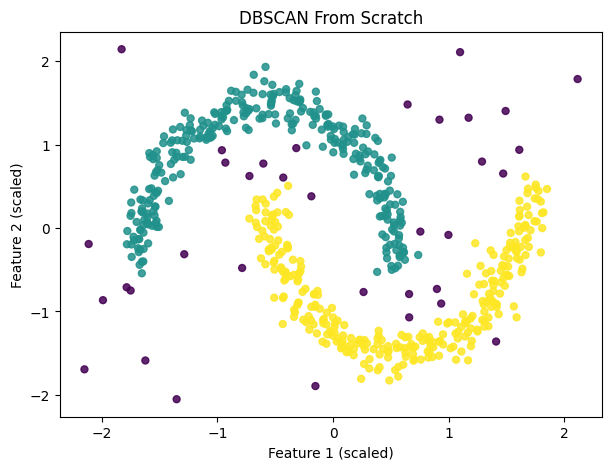

Số cụm tìm được: 2
Số điểm noise: 35
Các nhãn cụm: [np.int64(-1), np.int64(0), np.int64(1)]


In [8]:
scratch_dbscan = DBSCANFromScratch(eps=EPS, min_samples=MIN_SAMPLES)
scratch_labels = scratch_dbscan.fit_predict(X_scaled)

plot_2d_clusters(X_scaled, scratch_labels, 'DBSCAN From Scratch')
plt.show()

print('Số cụm tìm được:', len(set(scratch_labels)) - (1 if -1 in scratch_labels else 0))
print('Số điểm noise:', np.sum(scratch_labels == -1))
print('Các nhãn cụm:', sorted(set(scratch_labels)))

## 9. Chạy DBSCAN bằng sklearn

Phần này dùng `sklearn.cluster.DBSCAN` để đối chiếu với thuật toán tự triển khai.

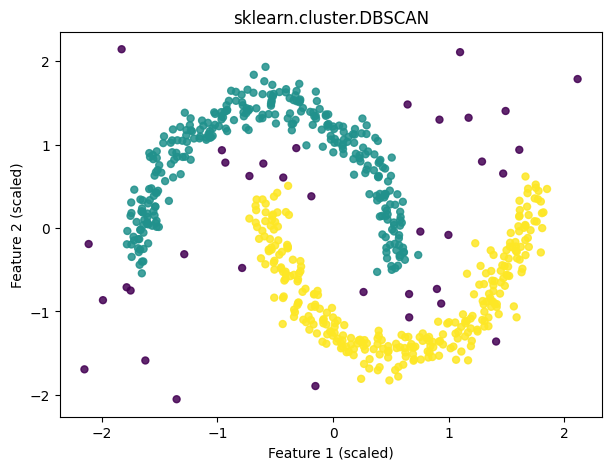

Số cụm tìm được: 2
Số điểm noise: 35
Các nhãn cụm: [np.int64(-1), np.int64(0), np.int64(1)]


In [9]:
sklearn_dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
sklearn_labels = sklearn_dbscan.fit_predict(X_scaled)

plot_2d_clusters(X_scaled, sklearn_labels, 'sklearn.cluster.DBSCAN')
plt.show()

print('Số cụm tìm được:', len(set(sklearn_labels)) - (1 if -1 in sklearn_labels else 0))
print('Số điểm noise:', np.sum(sklearn_labels == -1))
print('Các nhãn cụm:', sorted(set(sklearn_labels)))

## 10. Hàm đánh giá kết quả phân cụm

Với dữ liệu thật không có nhãn, có thể dùng các chỉ số nội tại như:

- `Silhouette Score`: càng cao càng tốt.
- `Davies-Bouldin Index`: càng thấp càng tốt.
- `Calinski-Harabasz Index`: càng cao càng tốt.

Với dummy data, ta có thêm `ARI` để kiểm tra minh họa vì dummy data có nhãn thật. Khi áp dụng vào dữ liệu khách hàng thật, không cần dùng `ARI_vs_dummy_label`.

In [10]:
def count_clusters(labels):
    labels = np.asarray(labels)
    n_noise = int(np.sum(labels == -1))
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    return n_clusters, n_noise


def evaluate_clustering(X, labels, y_true=None, model_name='model'):
    labels = np.asarray(labels)
    n_clusters, n_noise = count_clusters(labels)

    result = {
        'model': model_name,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_ratio': round(n_noise / len(labels), 4),
        'silhouette': np.nan,
        'davies_bouldin': np.nan,
        'calinski_harabasz': np.nan,
        'ARI_vs_dummy_label': np.nan,
    }

    # Với DBSCAN, loại noise khi tính các metric nội tại để đánh giá cấu trúc cụm chính.
    valid_mask = labels != -1
    valid_labels = labels[valid_mask]

    if len(set(valid_labels)) >= 2 and valid_mask.sum() > len(set(valid_labels)):
        result['silhouette'] = round(float(silhouette_score(X[valid_mask], valid_labels)), 4)
        result['davies_bouldin'] = round(float(davies_bouldin_score(X[valid_mask], valid_labels)), 4)
        result['calinski_harabasz'] = round(float(calinski_harabasz_score(X[valid_mask], valid_labels)), 4)

    if y_true is not None:
        result['ARI_vs_dummy_label'] = round(float(adjusted_rand_score(y_true, labels)), 4)

    return result

## 11. So sánh DBSCAN From Scratch và sklearn DBSCAN

Do cách đánh số cụm có thể khác nhau giữa các thuật toán, không nên so sánh trực tiếp từng nhãn `0`, `1`, `2`. Thay vào đó, dùng `Adjusted Rand Index` để kiểm tra hai cách phân cụm có tương đồng hay không.

In [11]:
comparison_df = pd.DataFrame([
    evaluate_clustering(X_scaled, scratch_labels, y_true, 'DBSCAN From Scratch'),
    evaluate_clustering(X_scaled, sklearn_labels, y_true, 'sklearn DBSCAN'),
])

ari_scratch_vs_sklearn = adjusted_rand_score(scratch_labels, sklearn_labels)

display(comparison_df)
print(f'ARI giữa From Scratch và sklearn DBSCAN: {ari_scratch_vs_sklearn:.4f}')

,model,n_clusters,n_noise,noise_ratio,silhouette,davies_bouldin,calinski_harabasz,ARI_vs_dummy_label
0,DBSCAN From Scratch,2,35,0.0543,0.395,1.0046,547.5716,0.9051
1,sklearn DBSCAN,2,35,0.0543,0.395,1.0046,547.5716,0.9051


ARI giữa From Scratch và sklearn DBSCAN: 1.0000


## 12. So sánh DBSCAN với K-Means trên dữ liệu không có dạng hình cầu

K-Means hoạt động tốt khi cụm có xu hướng hình cầu và có tâm cụm rõ ràng. Với dữ liệu dạng hai nửa vòng tròn, K-Means thường chia cụm theo khoảng cách đến centroid nên kết quả dễ bị sai về mặt hình dạng.

DBSCAN phù hợp hơn trong trường hợp này vì thuật toán mở rộng cụm theo mật độ điểm dữ liệu.

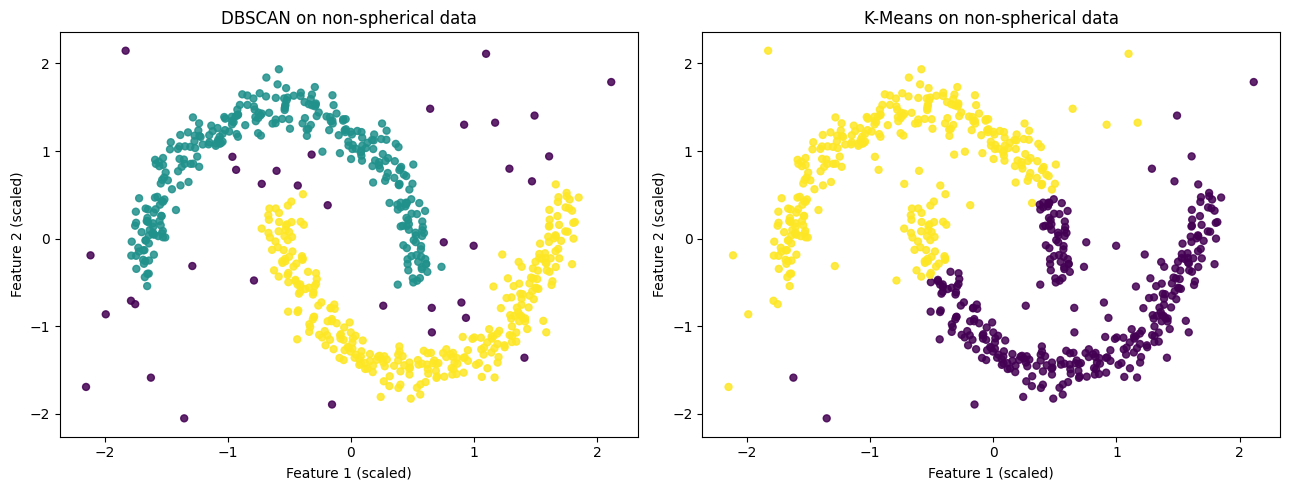

,model,n_clusters,n_noise,noise_ratio,silhouette,davies_bouldin,calinski_harabasz,ARI_vs_dummy_label
0,DBSCAN,2,35,0.0543,0.3950,1.0046,547.5716,0.9051
1,K-Means,2,0,0.0000,0.4783,0.8479,786.8816,0.3951


In [12]:
n_clusters_dbscan, _ = count_clusters(sklearn_labels)
kmeans_k = max(n_clusters_dbscan, 2)

kmeans = KMeans(n_clusters=kmeans_k, random_state=RANDOM_STATE, n_init='auto')
kmeans_labels = kmeans.fit_predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_2d_clusters(X_scaled, sklearn_labels, 'DBSCAN on non-spherical data', ax=axes[0])
plot_2d_clusters(X_scaled, kmeans_labels, 'K-Means on non-spherical data', ax=axes[1])
plt.tight_layout()
plt.show()

model_comparison_df = pd.DataFrame([
    evaluate_clustering(X_scaled, sklearn_labels, y_true, 'DBSCAN'),
    evaluate_clustering(X_scaled, kmeans_labels, y_true, 'K-Means'),
])

display(model_comparison_df)

## 13. Nhận xét kết quả

Với dummy data dạng `make_moons`, DBSCAN thường cho kết quả trực quan tốt hơn K-Means vì:

- DBSCAN gom cụm theo mật độ nên có thể nhận ra cụm có hình dạng cong.
- DBSCAN tự phát hiện điểm noise/outlier bằng nhãn `-1`.
- K-Means cần khai báo trước số cụm `K` và thường giả định cụm xoay quanh centroid, nên không phù hợp với dữ liệu không có dạng hình cầu.

Tuy nhiên, khi chuyển sang dữ liệu khách hàng thật, cần lưu ý:

- DBSCAN rất nhạy với `eps` và cách scale dữ liệu.
- Nếu dữ liệu có nhiều chiều sau one-hot encoding, khoảng cách Euclidean có thể kém hiệu quả hơn.
- Cần thử nhiều tổ hợp `eps`, `min_samples` và so sánh bằng các metric nội tại.

## 14. Hàm chạy DBSCAN tổng quát cho dữ liệu thật sau này

Sau khi nhóm hoàn thiện preprocessing/feature engineering, có thể dùng hàm này để chạy nhanh trên `ready_for_train.csv`.

In [13]:
def run_dbscan_pipeline(X, eps=None, min_samples=5, eps_percentile=92):
    """
    Pipeline tổng quát:
    1. Scale dữ liệu.
    2. Gợi ý eps bằng k-distance nếu eps chưa được truyền vào.
    3. Chạy DBSCAN sklearn.
    4. Trả về labels, model và bảng metric.
    """
    X_scaled, fitted_scaler = scale_features(X)

    if eps is None:
        kth_distances = k_distance_values(X_scaled, min_samples=min_samples)
        eps = suggest_eps_by_percentile(kth_distances, percentile=eps_percentile)

    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X_scaled)
    metrics = evaluate_clustering(X_scaled, labels, y_true=None, model_name='DBSCAN')

    return {
        'X_scaled': X_scaled,
        'scaler': fitted_scaler,
        'model': model,
        'labels': labels,
        'eps': eps,
        'min_samples': min_samples,
        'metrics': pd.DataFrame([metrics]),
    }


# Ví dụ dùng lại pipeline với dữ liệu hiện tại
pipeline_result = run_dbscan_pipeline(X_raw, min_samples=MIN_SAMPLES)
print('eps used:', round(pipeline_result['eps'], 4))
display(pipeline_result['metrics'])

eps used: 0.1781


,model,n_clusters,n_noise,noise_ratio,silhouette,davies_bouldin,calinski_harabasz,ARI_vs_dummy_label
0,DBSCAN,2,35,0.0543,0.395,1.0046,547.5716,NaN


## 15. Kết luận phần DBSCAN

Trong phạm vi nhiệm vụ DBSCAN của Practice 3, notebook đã hoàn thành các nội dung:

- Sinh dummy data để test thuật toán khi chưa có `ready_for_train.csv`.
- Triển khai DBSCAN From Scratch, không dùng sklearn ở phần thuật toán thủ công.
- Chạy DBSCAN bằng `sklearn.cluster.DBSCAN` để đối chiếu.
- Tìm `eps` bằng k-distance plot.
- So sánh DBSCAN với K-Means trên dữ liệu không có dạng hình cầu.
- Chuẩn bị sẵn hàm pipeline để thay bằng dữ liệu thật sau khi nhóm hoàn thiện preprocessing/feature engineering.

Khi push lên GitHub, chỉ nên push file notebook triển khai thuật toán. Không cần push dummy dataset vì dữ liệu minh họa đã được sinh trực tiếp trong notebook.

## 16. Gợi ý tên file khi đưa vào repo

Nên đặt notebook trong thư mục `practice_3` với tên:

```text
03-dbscan.ipynb
```

hoặc nếu nhóm đang chia theo thứ tự thuật toán:

```text
03-dbscan-clustering.ipynb
```